# Tip-Adapter: Training-Free Few-Shot Adaptation of CLIP

This notebook implements **Tip-Adapter** (Zhang et al., ECCV 2022) on top of pretrained CLIP (ViT-B/32), evaluated on CIFAR-10, and compares it against the Zero-Shot CLIP baseline from `CLIP_BLIP_Demo.ipynb`.

Tip-Adapter builds a **non-parametric key-value cache** from a small set of labeled (few-shot) training images — no gradient-based training required. We also implement **Tip-Adapter-F**, which fine-tunes the cache keys with a few epochs of SGD for a further accuracy boost.

**Method summary (from the paper):**
- Cache keys: L2-normalized CLIP image features of the K-shot training set, `F_train` (shape `[N*K, C]`)
- Cache values: one-hot labels, `L_train` (shape `[N*K, N]`)
- Affinity between a test image feature `f_test` and the cache: `A = exp(-beta * (1 - f_test @ F_train^T))`
- Final logits: `logits = alpha * (A @ L_train) + f_test @ W_c^T`, where `W_c` is CLIP's zero-shot text classifier
- Tip-Adapter-F: unfreeze `F_train` (the cache keys) and fine-tune with SGD for a few epochs, everything else stays frozen

---

In [1]:
# ── Install required packages ──────────────────────────────────────────────
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

print("\u2705 All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All packages installed successfully!


In [2]:
# ── Core imports ───────────────────────────────────────────────────────────
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset

import warnings
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {DEVICE.upper()}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("\u26a0\ufe0f  No GPU found. Go to Runtime \u2192 Change runtime type \u2192 T4 GPU")

Running on: CPU
⚠️  No GPU found. Go to Runtime → Change runtime type → T4 GPU


---

## 1 — Load CLIP and CIFAR-10 (identical setup to `CLIP_BLIP_Demo.ipynb`, for a like-for-like comparison)

In [3]:
# ── Load CLIP model ────────────────────────────────────────────────────────
print("Loading CLIP model (ViT-B/32)...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()

print(f"\u2705 CLIP loaded!")
print(f"   Embedding dimension : {clip_model.visual.output_dim}")

Loading CLIP model (ViT-B/32)...


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 101MiB/s]


✅ CLIP loaded!
   Embedding dimension : 512


In [4]:
# ── Load CIFAR-10 (train split for the few-shot cache, test split for evaluation) ──
print("Downloading CIFAR-10...")

cifar_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True,
    transform=transforms.ToTensor()
)
raw_cifar10 = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True,
    transform=transforms.ToTensor()
)

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print(f"\u2705 CIFAR-10 loaded: {len(cifar_train)} train, {len(raw_cifar10)} test images")

100%|██████████| 170M/170M [17:05<00:00, 166kB/s]


✅ CIFAR-10 loaded: 50000 train, 10000 test images


In [5]:
# ── Build the SAME 500-image test subset used in CLIP_BLIP_Demo.ipynb (50/class) ──
indices_per_class = {c: [] for c in range(10)}
for idx, (_, label) in enumerate(raw_cifar10):
    if len(indices_per_class[label]) < 50:
        indices_per_class[label].append(idx)
    if all(len(v) == 50 for v in indices_per_class.values()):
        break

test_indices = [idx for idxs in indices_per_class.values() for idx in idxs]
test_subset  = Subset(raw_cifar10, test_indices)
print(f"Test set: {len(test_subset)} images (50 per class)")

Test set: 500 images (50 per class)


In [6]:
# ── Zero-shot text classifier W_c (CLIP's class-prompt embeddings) ──────────
text_prompts = [f"a photo of a {c}" for c in CIFAR10_CLASSES]
text_tokens  = clip.tokenize(text_prompts).to(DEVICE)

with torch.no_grad():
    text_features = clip_model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print(f"Text classifier W_c shape: {text_features.shape}")

Text classifier W_c shape: torch.Size([10, 512])


In [7]:
# ── Extract CLIP features for the test set (do ONCE, reuse for every K) ─────
def extract_features(dataset):
    feats, labels = [], []
    clip_model.eval()
    with torch.no_grad():
        for img_tensor, label in dataset:
            pil_img = transforms.ToPILImage()(img_tensor)
            inp = clip_preprocess(pil_img).unsqueeze(0).to(DEVICE)
            feat = clip_model.encode_image(inp)
            feat = feat / feat.norm(dim=-1, keepdim=True)
            feats.append(feat.cpu())
            labels.append(label)
    return torch.cat(feats, dim=0).float(), torch.tensor(labels)

print("Extracting CLIP test features...")
F_test, y_test = extract_features(test_subset)
print(f"F_test shape: {F_test.shape}")

Extracting CLIP test features...
F_test shape: torch.Size([500, 512])


In [8]:
# ── Zero-shot baseline accuracy on this test set (for comparison) ───────────
clip_logits_zs = 100.0 * (F_test.to(DEVICE) @ text_features.T)
zs_preds = clip_logits_zs.argmax(dim=1).cpu()
zeroshot_acc = (zs_preds == y_test).float().mean().item() * 100
print(f"Zero-shot CLIP accuracy on this test set: {zeroshot_acc:.1f}%")

Zero-shot CLIP accuracy on this test set: 90.4%


---

## 2 — Tip-Adapter (training-free) and Tip-Adapter-F (fine-tuned)

For each K, we build the cache from a fresh K-shot-per-class training subset, then evaluate both variants on the fixed 500-image test set above.

In [9]:
# ── Helper: build a K-shot-per-class subset of the CIFAR-10 train split ─────
def build_shot_subset(k):
    indices = []
    seen = {c: 0 for c in range(10)}
    for idx, (_, label) in enumerate(cifar_train):
        if seen[label] < k:
            indices.append(idx)
            seen[label] += 1
        if all(v == k for v in seen.values()):
            break
    return Subset(cifar_train, indices)

In [10]:
# ── Tip-Adapter core: build cache, compute affinity, get logits ─────────────
N_CLASSES = 10

def build_cache(k):
    """Returns F_train [NK, C] (cache keys) and L_train [NK, N] (one-hot cache values)."""
    shot_subset = build_shot_subset(k)
    F_train, y_train = extract_features(shot_subset)
    L_train = torch.nn.functional.one_hot(y_train, num_classes=N_CLASSES).float()
    return F_train, L_train, y_train

def tip_adapter_logits(F_train, L_train, F_query, beta, alpha, clip_logits):
    """Eq. 5-6 from the paper: logits = alpha * A @ L_train + clip_logits."""
    affinity = ((-1) * beta * (1 - F_query.to(DEVICE) @ F_train.to(DEVICE).T)).exp()
    cache_logits = affinity @ L_train.to(DEVICE)
    return alpha * cache_logits + clip_logits

def search_hyperparams(F_train, L_train, y_train, clip_logits_train,
                        beta_list=(1, 2, 3, 5, 8, 11, 15, 20),
                        alpha_list=(0.5, 1, 2, 3, 5, 8, 12, 20)):
    """Coarse grid search over (beta, alpha) using the few-shot training set itself
    as validation, following the low-shot search strategy in the original paper."""
    best_acc, best_beta, best_alpha = -1, beta_list[0], alpha_list[0]
    for beta in beta_list:
        for alpha in alpha_list:
            logits = tip_adapter_logits(F_train, L_train, F_train, beta, alpha, clip_logits_train)
            preds = logits.argmax(dim=1).cpu()
            acc = (preds == y_train).float().mean().item() * 100
            if acc > best_acc:
                best_acc, best_beta, best_alpha = acc, beta, alpha
    return best_beta, best_alpha

In [11]:
# ── Tip-Adapter-F: fine-tune the cache keys F_train with a few epochs of SGD ─
def tip_adapter_finetune(F_train, L_train, y_train, clip_logits_train,
                          beta, alpha, epochs=20, lr=1e-3):
    """Only F_train (the adapter's first-layer weights) is trainable.
    Everything else (CLIP encoders, W_c, L_train) stays frozen, matching the paper."""
    adapter_keys = F_train.clone().to(DEVICE).requires_grad_(True)
    optimizer = torch.optim.AdamW([adapter_keys], lr=lr, eps=1e-4)
    criterion = torch.nn.CrossEntropyLoss()
    y_train_dev = y_train.to(DEVICE)

    for epoch in range(epochs):
        affinity = ((-1) * beta * (1 - F_train.to(DEVICE) @ adapter_keys.T)).exp()
        cache_logits = affinity @ L_train.to(DEVICE)
        logits = alpha * cache_logits + clip_logits_train
        loss = criterion(logits, y_train_dev)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return adapter_keys.detach().cpu()

In [12]:
# ── Run the full K-shot sweep: Zero-shot vs. Tip-Adapter vs. Tip-Adapter-F ──
K_VALUES = [1, 5, 10, 50, 100]
results = {'zeroshot': zeroshot_acc, 'tip_adapter': {}, 'tip_adapter_f': {}, 'hparams': {}}

print(f"{'K':>5} {'Zero-shot':>10} {'Tip-Adapter':>13} {'Tip-Adapter-F':>15}   (beta, alpha)")
print("-" * 68)

for k in K_VALUES:
    F_train, L_train, y_train = build_cache(k)

    clip_logits_train = 100.0 * (F_train.to(DEVICE) @ text_features.T)
    beta, alpha = search_hyperparams(F_train, L_train, y_train, clip_logits_train)
    results['hparams'][k] = (beta, alpha)

    # Training-free Tip-Adapter
    logits_ta = tip_adapter_logits(F_train, L_train, F_test, beta, alpha, clip_logits_zs)
    preds_ta = logits_ta.argmax(dim=1).cpu()
    acc_ta = (preds_ta == y_test).float().mean().item() * 100
    results['tip_adapter'][k] = acc_ta

    # Fine-tuned Tip-Adapter-F
    epochs = 20 if k <= 20 else 10  # fewer epochs for larger K to control runtime
    tuned_keys = tip_adapter_finetune(F_train, L_train, y_train, clip_logits_train,
                                       beta, alpha, epochs=epochs)
    logits_taf = tip_adapter_logits(tuned_keys, L_train, F_test, beta, alpha, clip_logits_zs)
    preds_taf = logits_taf.argmax(dim=1).cpu()
    acc_taf = (preds_taf == y_test).float().mean().item() * 100
    results['tip_adapter_f'][k] = acc_taf

    print(f"{k:>5} {zeroshot_acc:>9.1f}% {acc_ta:>12.1f}% {acc_taf:>14.1f}%   (\u03b2={beta}, \u03b1={alpha})")

print("-" * 68)

    K  Zero-shot   Tip-Adapter   Tip-Adapter-F   (beta, alpha)
--------------------------------------------------------------------
    1      90.4%         91.6%           90.4%   (β=1, α=12)
    5      90.4%         91.0%           89.2%   (β=15, α=8)
   10      90.4%         92.2%           90.6%   (β=20, α=8)
   50      90.4%         88.4%           89.0%   (β=20, α=20)
  100      90.4%         89.2%           91.6%   (β=20, α=8)
--------------------------------------------------------------------


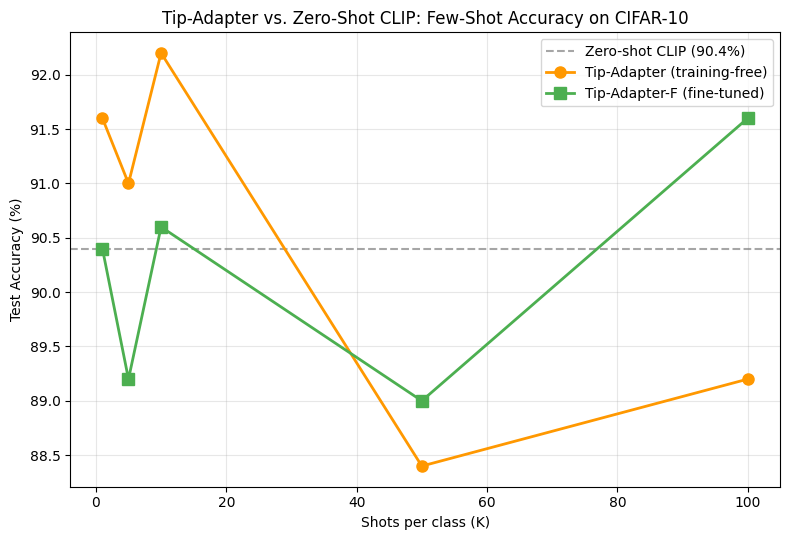

In [13]:
# ── Plot: Zero-shot vs. Tip-Adapter vs. Tip-Adapter-F across K ───────────────
plt.figure(figsize=(8, 5.5))

plt.axhline(zeroshot_acc, color='gray', linestyle='--', alpha=0.7,
            label=f'Zero-shot CLIP ({zeroshot_acc:.1f}%)')
plt.plot(K_VALUES, [results['tip_adapter'][k] for k in K_VALUES],
         'o-', linewidth=2, markersize=8, color='#FF9800', label='Tip-Adapter (training-free)')
plt.plot(K_VALUES, [results['tip_adapter_f'][k] for k in K_VALUES],
         's-', linewidth=2, markersize=8, color='#4CAF50', label='Tip-Adapter-F (fine-tuned)')

plt.xlabel('Shots per class (K)')
plt.ylabel('Test Accuracy (%)')
plt.title('Tip-Adapter vs. Zero-Shot CLIP: Few-Shot Accuracy on CIFAR-10')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tip_adapter_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 3 — Summary table (for Table 4.1 / Section 6.2 of the report)

In [14]:
# ── Final summary ─────────────────────────────────────────────────────────
print("=" * 60)
print("  TIP-ADAPTER — SUMMARY")
print("=" * 60)
print(f"\nZero-shot CLIP (K=0)        : {zeroshot_acc:.1f}%")
print(f"\n{'K':>5} {'Tip-Adapter':>13} {'Tip-Adapter-F':>15} {'(beta, alpha)':>18}")
for k in K_VALUES:
    beta, alpha = results['hparams'][k]
    print(f"{k:>5} {results['tip_adapter'][k]:>12.1f}% {results['tip_adapter_f'][k]:>14.1f}%   "
          f"(\u03b2={beta}, \u03b1={alpha})")
print("\nNote: Tip-Adapter is training-free (no backprop through the cache).")
print("Tip-Adapter-F fine-tunes only the cache keys via SGD, matching Zhang et al. (ECCV 2022).")

  TIP-ADAPTER — SUMMARY

Zero-shot CLIP (K=0)        : 90.4%

    K   Tip-Adapter   Tip-Adapter-F      (beta, alpha)
    1         91.6%           90.4%   (β=1, α=12)
    5         91.0%           89.2%   (β=15, α=8)
   10         92.2%           90.6%   (β=20, α=8)
   50         88.4%           89.0%   (β=20, α=20)
  100         89.2%           91.6%   (β=20, α=8)

Note: Tip-Adapter is training-free (no backprop through the cache).
Tip-Adapter-F fine-tunes only the cache keys via SGD, matching Zhang et al. (ECCV 2022).
